In [ ]:
from pathlib import Path
import json, pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'data' / 'processed' / 'svm').is_dir():
            return candidate
    raise FileNotFoundError('Không thấy data/processed/svm.')

ROOT = find_project_root(Path.cwd().resolve())
DATA_DIR = ROOT / 'data' / 'processed' / 'svm'
MODEL_DIR = ROOT / 'model' / 'svm'
action_dirs = sorted(path for path in DATA_DIR.iterdir() if path.is_dir())
actions, X, y, skipped_actions = [], [], [], []
for action_dir in action_dirs:
    files = sorted(action_dir.glob('*.npy'))
    if not files:
        skipped_actions.append(action_dir.name)
        continue
    label_index = len(actions)
    actions.append(action_dir.name)
    for file in files:
        X.append(np.load(file))
        y.append(label_index)
label_map = {name: index for index, name in enumerate(actions)}
X, y = np.asarray(X, dtype=np.float32), np.asarray(y)
assert len(actions) >= 2 and len(X) > 0, 'Cần ít nhất hai lớp và dữ liệu hợp lệ.'
if skipped_actions:
    print(f'Bỏ qua thư mục nhãn rỗng: {skipped_actions}')
print(f'Lớp dùng để train: {actions}')
print(f'Dữ liệu: {X.shape}  (mẫu, đặc trưng)')
print('Số mẫu mỗi lớp:', {name: int((y == index).sum()) for name, index in label_map.items()})

Bỏ qua thư mục nhãn rỗng: ['0']
Lớp dùng để train: ['1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']
Dữ liệu: (3960, 63)  (mẫu, đặc trưng)
Số mẫu mỗi lớp: {'1': 120, '2': 120, '3': 120, '4': 120, '5': 120, '6': 120, '7': 120, '8': 120, '9': 120, 'A': 120, 'B': 120, 'C': 120, 'D': 120, 'E': 120, 'F': 120, 'G': 120, 'H': 120, 'I': 120, 'K': 120, 'L': 120, 'M': 120, 'N': 120, 'O': 120, 'P': 120, 'Q': 120, 'R': 120, 'S': 120, 'T': 120, 'U': 120, 'V': 120, 'W': 120, 'X': 120, 'Y': 120}


Test accuracy: 97.60%
              precision    recall  f1-score   support

           1       1.00      0.83      0.91        24
           2       0.86      1.00      0.92        24
           3       0.89      1.00      0.94        24
           4       0.91      0.88      0.89        24
           5       1.00      0.92      0.96        24
           6       0.96      1.00      0.98        24
           7       1.00      0.96      0.98        24
           8       1.00      1.00      1.00        24
           9       1.00      1.00      1.00        24
           A       1.00      1.00      1.00        24
           B       1.00      1.00      1.00        24
           C       1.00      1.00      1.00        24
           D       1.00      1.00      1.00        24
           E       1.00      1.00      1.00        24
           F       1.00      1.00      1.00        24
           G       1.00      1.00      1.00        24
           H       1.00      1.00      1.00        24
     

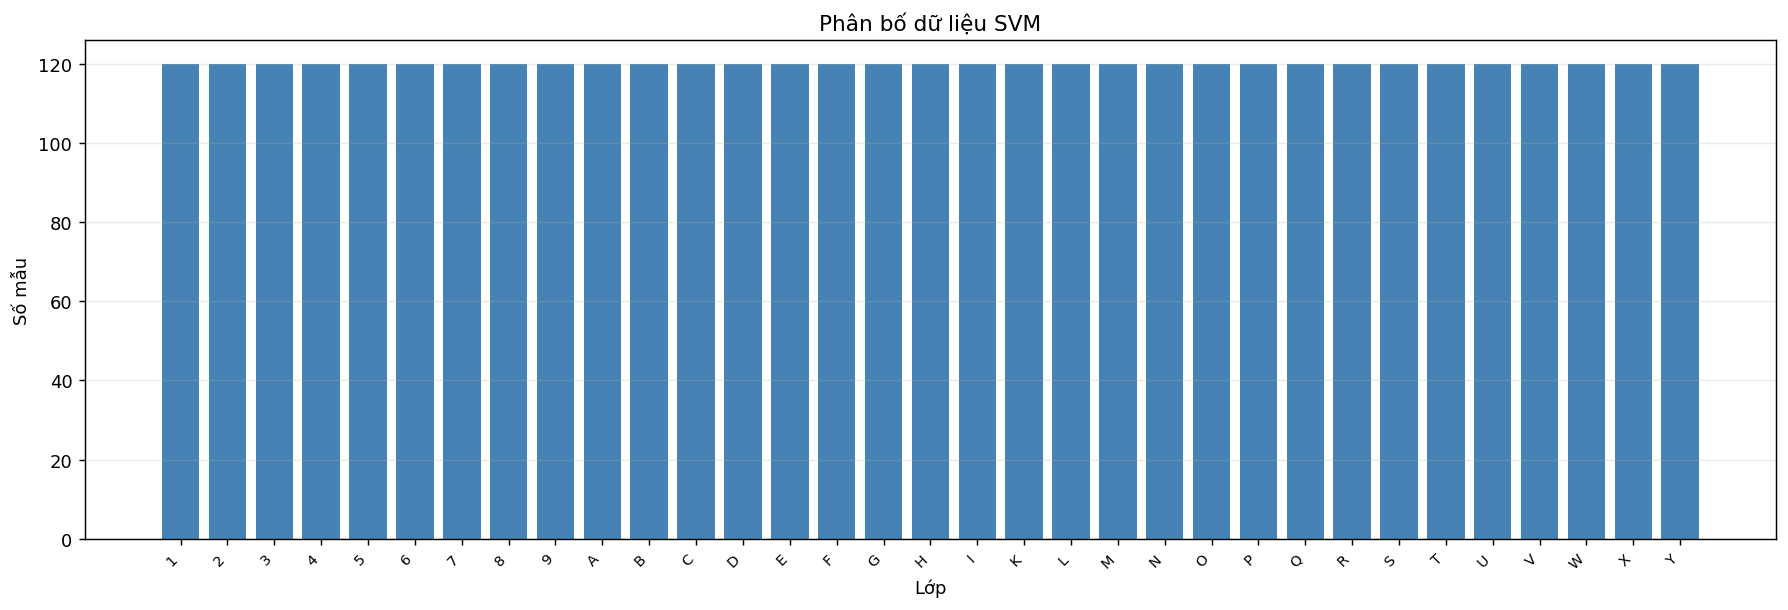

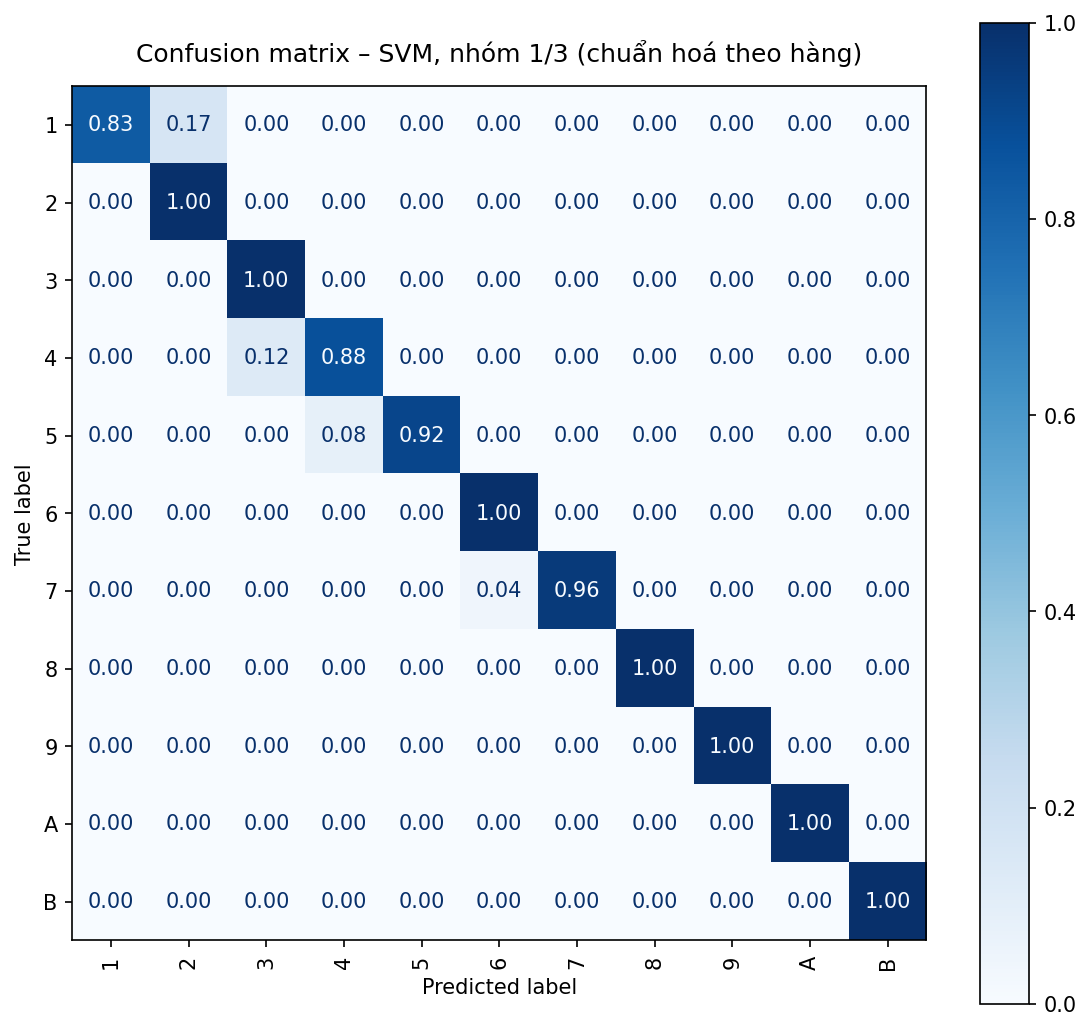

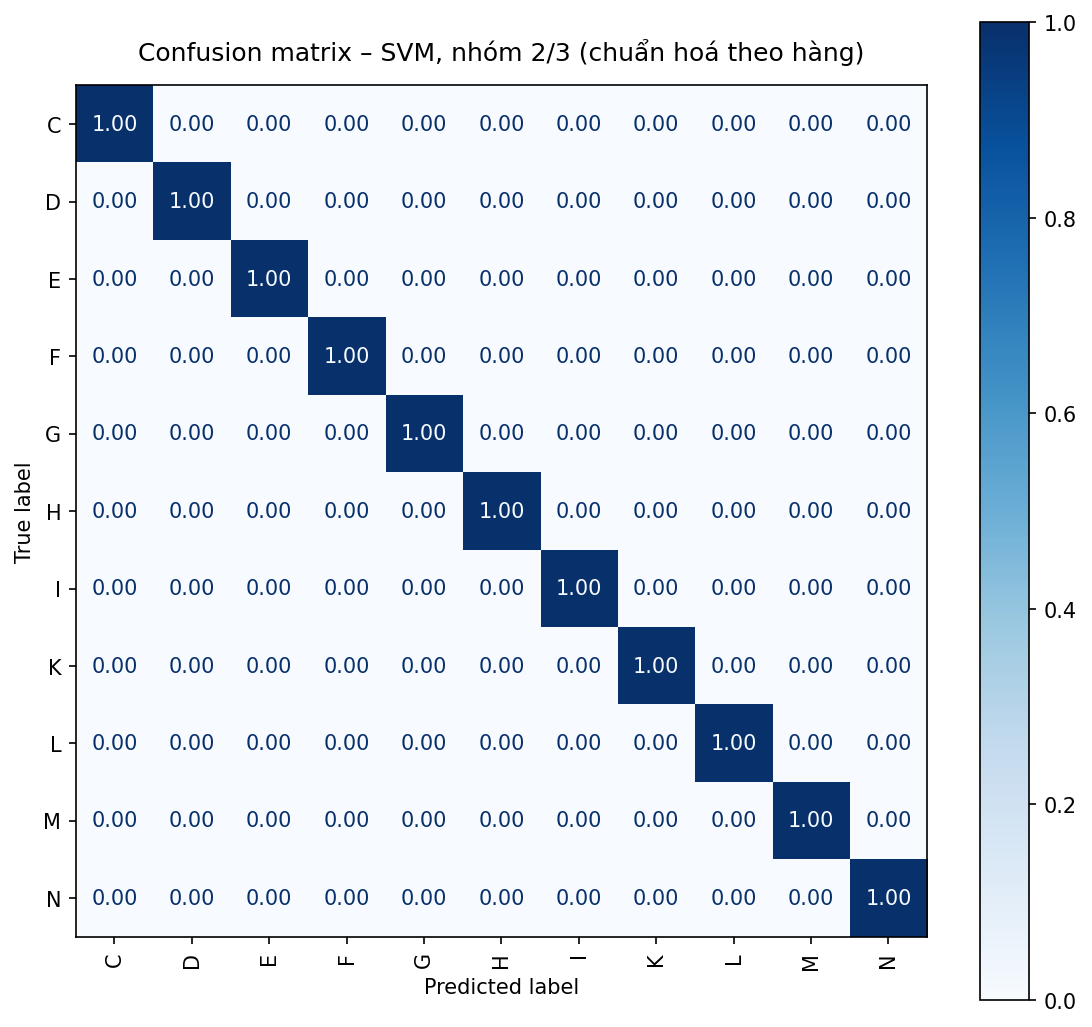

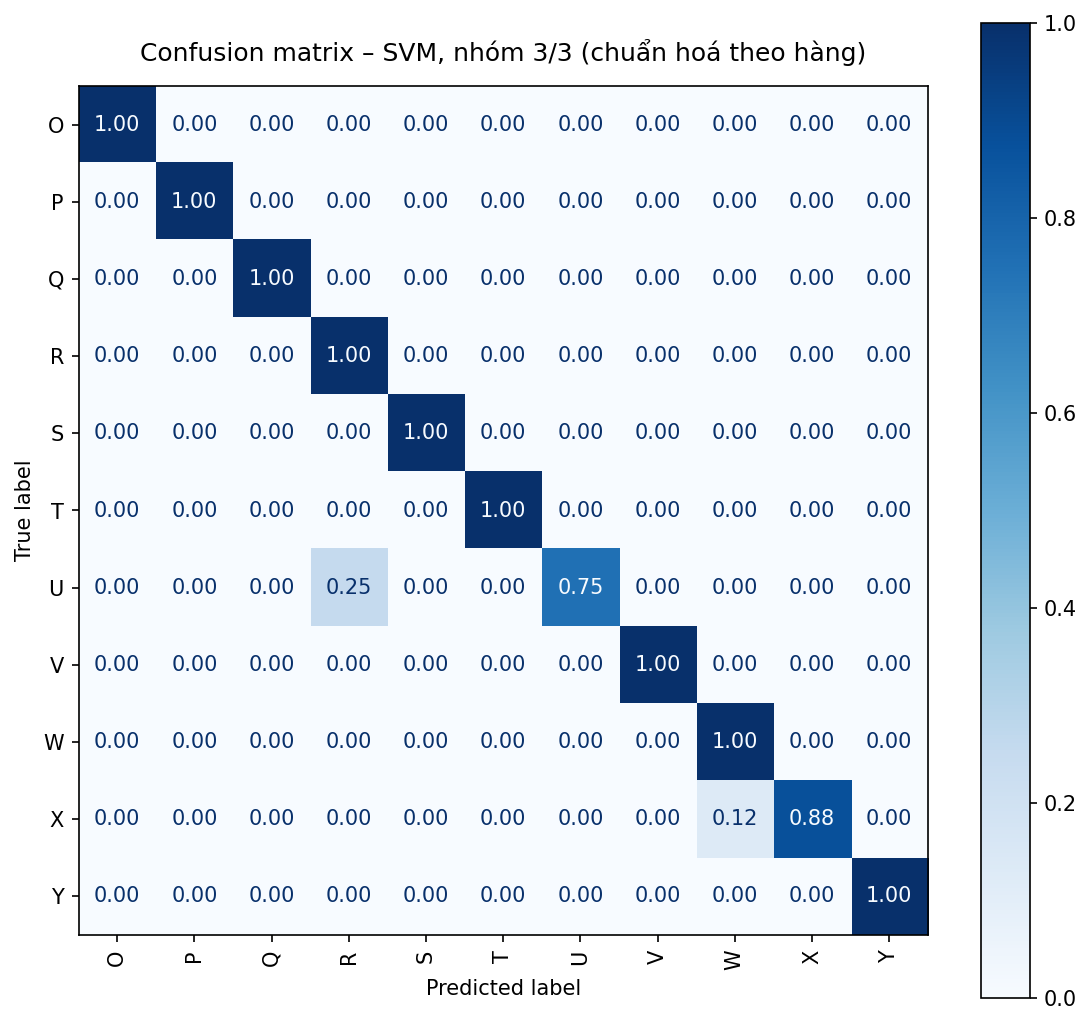

Các cặp bị nhầm nhiều nhất (nhãn thật → nhãn dự đoán):
  U → R: 6 mẫu
  1 → 2: 4 mẫu
  X → W: 3 mẫu
  4 → 3: 3 mẫu
  5 → 4: 2 mẫu
  7 → 6: 1 mẫu
Đã lưu model/svm/svm_model.pkl và labels.json


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = make_pipeline(StandardScaler(), SVC(kernel='rbf', C=3, probability=True, random_state=42))
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Test accuracy: {accuracy:.2%}')
print(classification_report(
    y_test, y_pred, labels=np.arange(len(actions)),
    target_names=actions, zero_division=0
))
n_classes = len(actions)
counts = [int((y == index).sum()) for index in range(n_classes)]
fig, ax = plt.subplots(figsize=(max(12, n_classes * 0.42), 4.8), dpi=130)
ax.bar(range(n_classes), counts, color='steelblue')
ax.set(title='Phân bố dữ liệu SVM', xlabel='Lớp', ylabel='Số mẫu')
ax.set_xticks(range(n_classes), actions, rotation=45, ha='right', fontsize=8)
ax.grid(axis='y', alpha=0.25)
fig.tight_layout(); plt.show()
cm_counts = confusion_matrix(y_test, y_pred, labels=np.arange(n_classes))
cm = confusion_matrix(y_test, y_pred, labels=np.arange(n_classes), normalize='true')
max_classes_per_matrix = 11
group_count = (n_classes + max_classes_per_matrix - 1) // max_classes_per_matrix
for group_number, start in enumerate(range(0, n_classes, max_classes_per_matrix), start=1):
    stop = min(start + max_classes_per_matrix, n_classes)
    indices = np.arange(start, stop)
    group_labels = actions[start:stop]
    group_cm = cm[np.ix_(indices, indices)]
    fig, ax = plt.subplots(figsize=(7.8, 7.0), dpi=150)
    display = ConfusionMatrixDisplay(confusion_matrix=group_cm, display_labels=group_labels)
    display.plot(
        ax=ax, cmap='Blues', colorbar=True, xticks_rotation='vertical',
        include_values=True, values_format='.2f'
    )
    ax.set_title(
        f'Confusion matrix – SVM, nhóm {group_number}/{group_count} (chuẩn hoá theo hàng)',
        pad=12
    )
    ax.tick_params(axis='both', labelsize=10)
    fig.tight_layout(); plt.show()
errors = [
    (int(cm_counts[true_index, pred_index]), actions[true_index], actions[pred_index])
    for true_index in range(n_classes)
    for pred_index in range(n_classes)
    if true_index != pred_index and cm_counts[true_index, pred_index] > 0
]
if errors:
    print('Các cặp bị nhầm nhiều nhất (nhãn thật → nhãn dự đoán):')
    for count, true_label, pred_label in sorted(errors, reverse=True)[:10]:
        print(f'  {true_label} → {pred_label}: {count} mẫu')
else:
    print('Không có sai trên test')

MODEL_DIR.mkdir(parents=True, exist_ok=True)
with open(MODEL_DIR / 'svm_model.pkl', 'wb') as file:
    pickle.dump(model, file)
(MODEL_DIR / 'labels.json').write_text(json.dumps(actions, ensure_ascii=False), encoding='utf-8')
print('Đã lưu model/svm/svm_model.pkl và labels.json')
